# Importações

In [ ]:
from utils.common import import_dataframe

from utils.common import seasonal_plot, plot_periodogram
from utils.common import plot_lags, make_lags, make_leads, make_multistep_target

from utils.common import print_equation, plot_params, plot_linear_model
from utils.common import calculate_metrics

from utils.common import HybridDirect, HybridRecursive, HybridDirRec
from utils.common import plot_plotly, plot_multistep_plotly

from utils.common import get_model_name

import pandas as pd
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.base import clone

# Volume

In [2]:
df = import_dataframe()

df_volume = df[["Data", "SC_VolumeTotalHm3"]].copy()
df_vazao_natural = df[["Data", "SC_VazaoNatural"]].copy()
df_vazao_jusante = df[["Data", "SC_VazaoJusante"]].copy()

df_volume = df_volume.set_index("Data")
df_vazao_natural = df_vazao_natural.set_index("Data")
df_vazao_jusante = df_vazao_jusante.set_index("Data")

df_volume_series = (
  df_volume
    .groupby('Data').mean()
    .squeeze()
)

df_vazao_natural_series = (
  df_vazao_natural
    .groupby('Data').mean()
    .squeeze()
)

df_vazao_jusante_series = (
  df_vazao_jusante
    .groupby('Data').mean()
    .squeeze()
)

c:\Users\marce\Desktop\Pos Graduacoes\UFSCAR - MachineLearningInProduction\AtividadesEntregas\4_TCC\codigo\tcc\analise\utils\common.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Data_num"] = df["Data"].apply(lambda x: x.toordinal() - minimo_data_numerica)


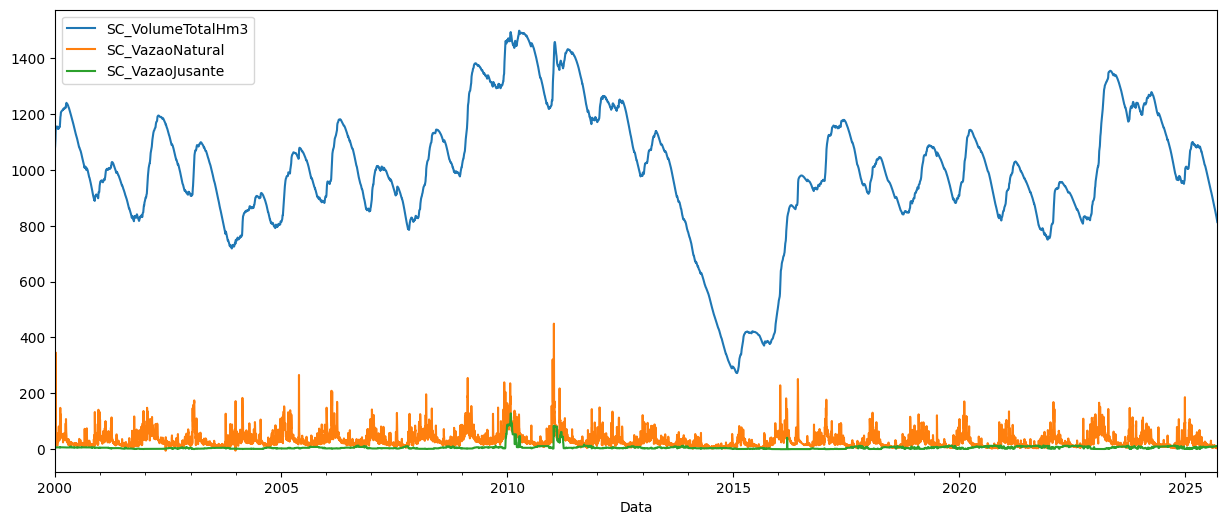

In [3]:
df_plot_vol = df[["Data", "SC_VolumeTotalHm3"]].copy()
df_plot_vn = df[["Data", "SC_VazaoNatural"]].copy()
df_plot_vj = df[["Data", "SC_VazaoJusante"]].copy()

df_plot_vol = df_plot_vol.set_index("Data")
df_plot_vn = df_plot_vn.set_index("Data")
df_plot_vj = df_plot_vj.set_index("Data")

plot_params = {
  'color': '0.75',
  'style': '.-',
  'markeredgecolor': '0.25',
  'markerfacecolor': '0.25',
  'legend': False
}

ax = df_plot_vol.plot(style='-', markeredgecolor='0.25', markerfacecolor='0.25', legend=False)
ax = df_plot_vn.plot(ax=ax, legend=False)
ax = df_plot_vj.plot(ax=ax, legend=False)
ax.legend()

## Verificar estacionariedade

In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(timeseries):
  print("Results of Dickey-Fuller Test:")
  dftest = adfuller(timeseries, autolag="AIC")
  dfoutput = pd.Series(
    dftest[0:4],
    index=[
      "Test Statistic",
      "p-value",
      "#Lags Used",
      "Number of Observations Used",
    ],
  )
  for key, value in dftest[4].items():
    dfoutput["Critical Value (%s)" % key] = value
  print(dfoutput)

def kpss_test(timeseries):
  print("Results of KPSS Test:")
  kpsstest = kpss(timeseries, regression="c", nlags="auto")
  kpss_output = pd.Series(
    kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
  )
  for key, value in kpsstest[3].items():
    kpss_output["Critical Value (%s)" % key] = value
  print(kpss_output)

In [5]:
print("*"*80)
adf_test(df_plot_vol)
print("*"*80)
kpss_test(df_plot_vol)
print("*"*80)

********************************************************************************
Results of Dickey-Fuller Test:
Test Statistic                   -3.757991
p-value                           0.003368
#Lags Used                       37.000000
Number of Observations Used    9353.000000
Critical Value (1%)              -3.431049
Critical Value (5%)              -2.861849
Critical Value (10%)             -2.566935
dtype: float64
********************************************************************************
Results of KPSS Test:
Test Statistic            0.684896
p-value                   0.014919
Lags Used                58.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
********************************************************************************


- O primeiro teste (ADF) teve resultado p-value menor que 0,05. Esse teste sugere que a série é estacionária.
- O segundo teste (KPSS) teve resultado p-value menor que 0,05. Esse teste sugere não ser estacionária.
- Testes inconclusivos.

## Análise de Sazonalidade

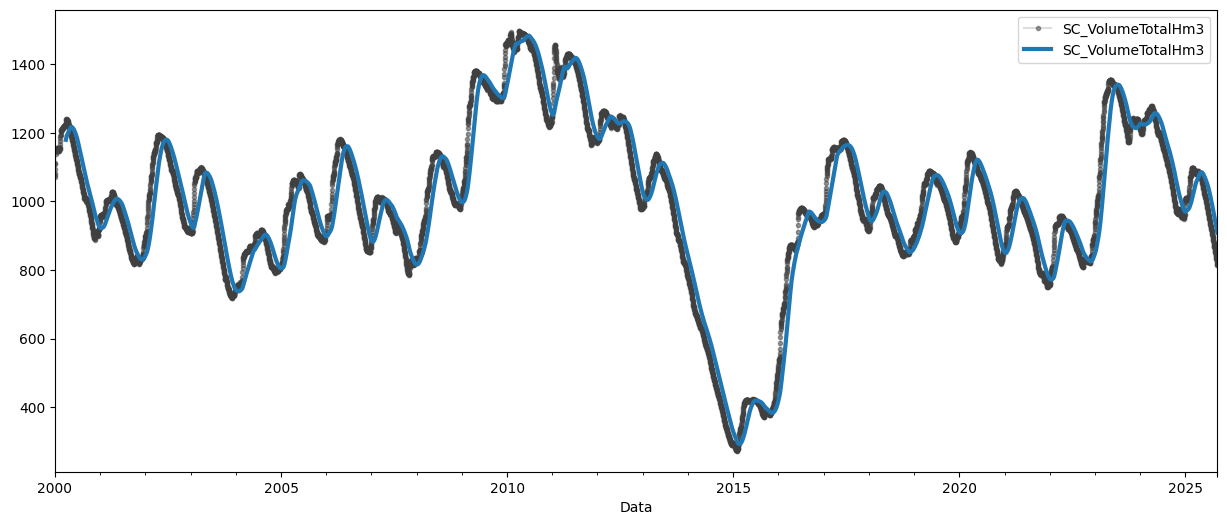

In [6]:
y = df_volume.copy()
trend = y.rolling(
  window=90,
).mean()

ax = y.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)
ax.legend()

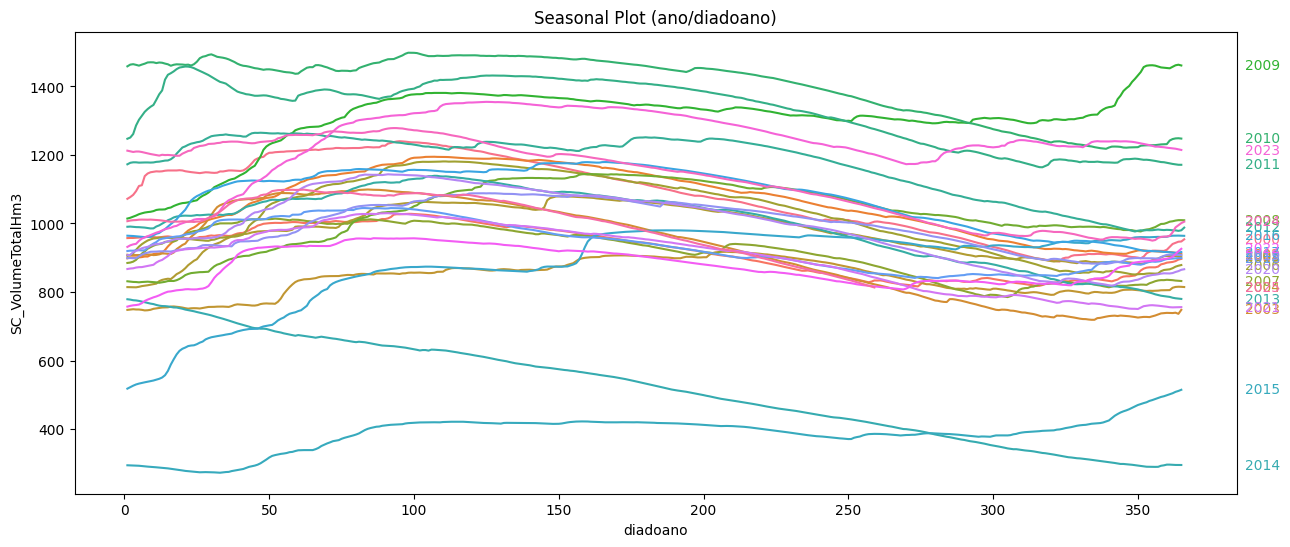

In [7]:
X = df_volume.copy()
X["ano"] = X.index.year
X["diadoano"] = X.index.dayofyear
seasonal_plot(X, y='SC_VolumeTotalHm3', period='ano', freq='diadoano');

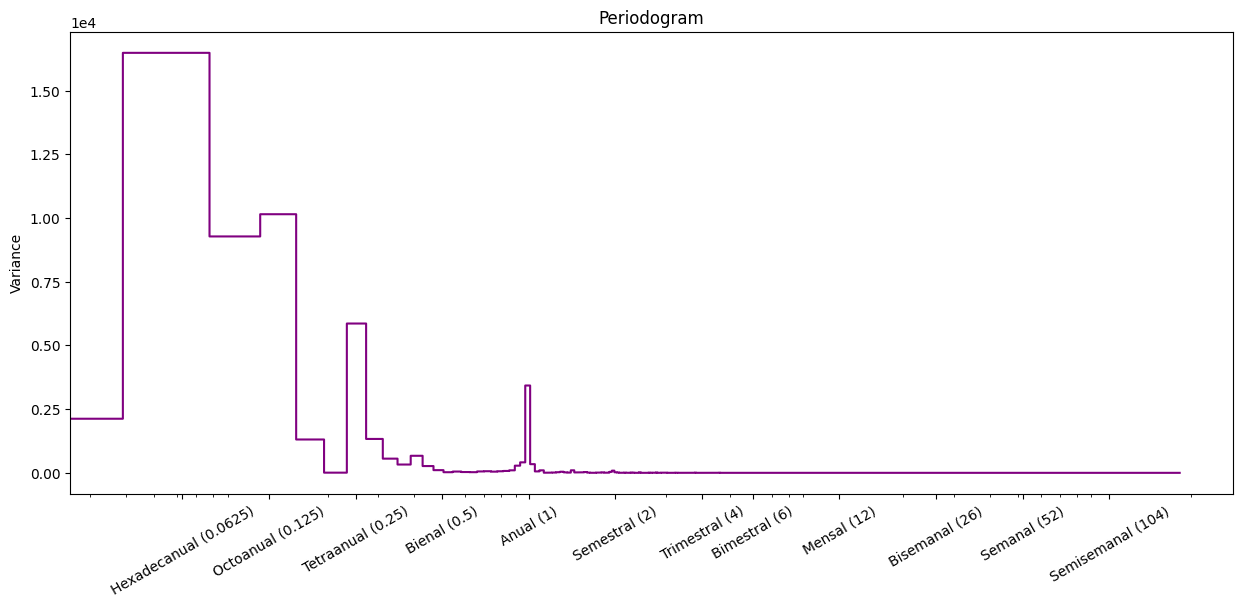

In [8]:
plot_periodogram(df_volume_series);

## Sazonalidade a partir de 2018

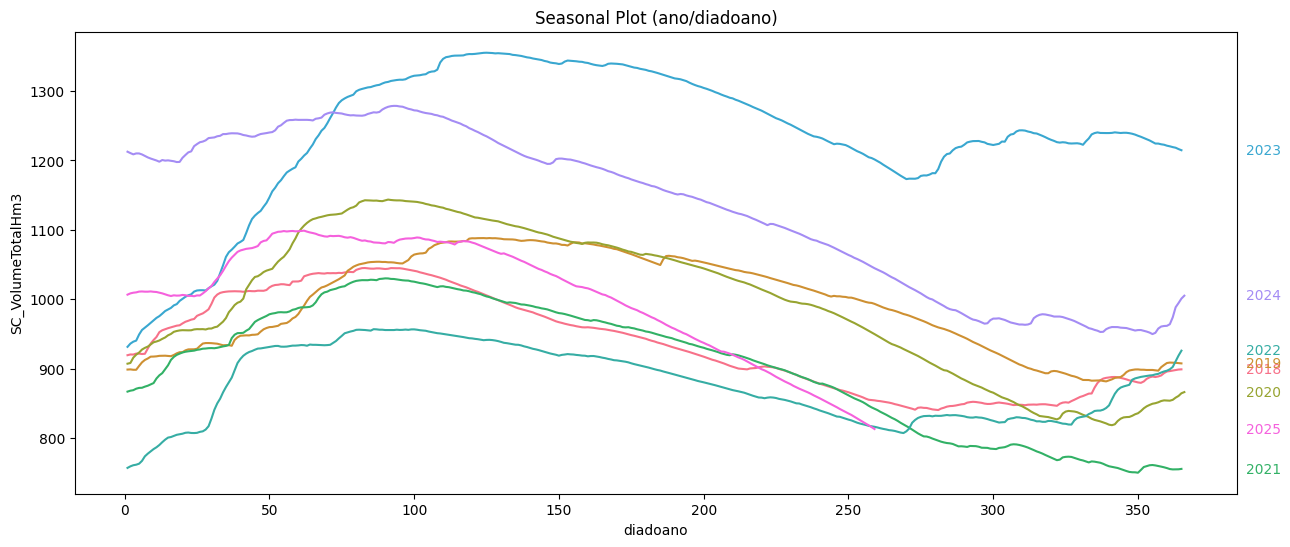

In [9]:
df_volume_recente = df_volume[df_volume.index >= "2018-01-01"].copy()
X = df_volume_recente.copy()
X["ano"] = X.index.year
X["diadoano"] = X.index.dayofyear
seasonal_plot(X, y='SC_VolumeTotalHm3', period='ano', freq='diadoano');

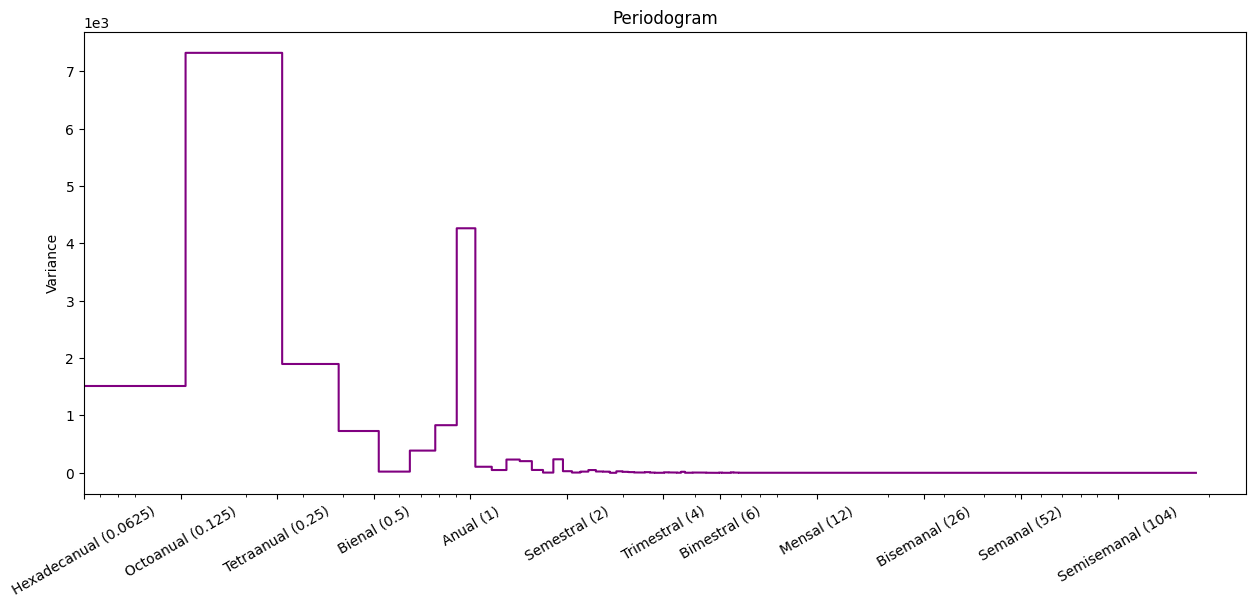

In [10]:
df_volume_recente_series = (
  df_volume_recente
    .groupby('Data').mean()
    .squeeze()
)
plot_periodogram(df_volume_recente_series);

# Ciclos

## Autocorrelação Parcial e Gráfico de Defasagem

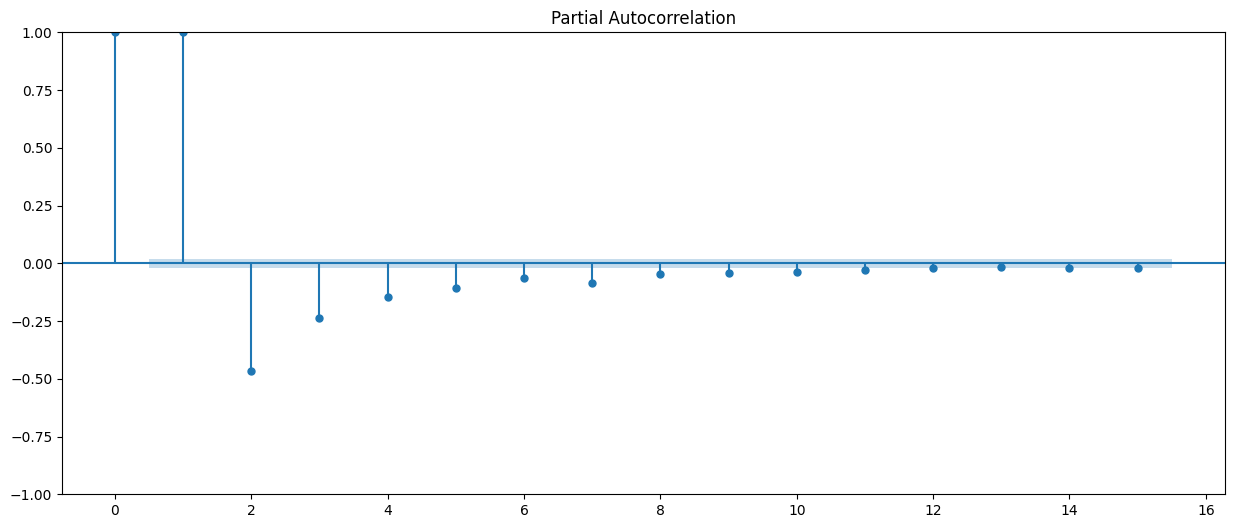

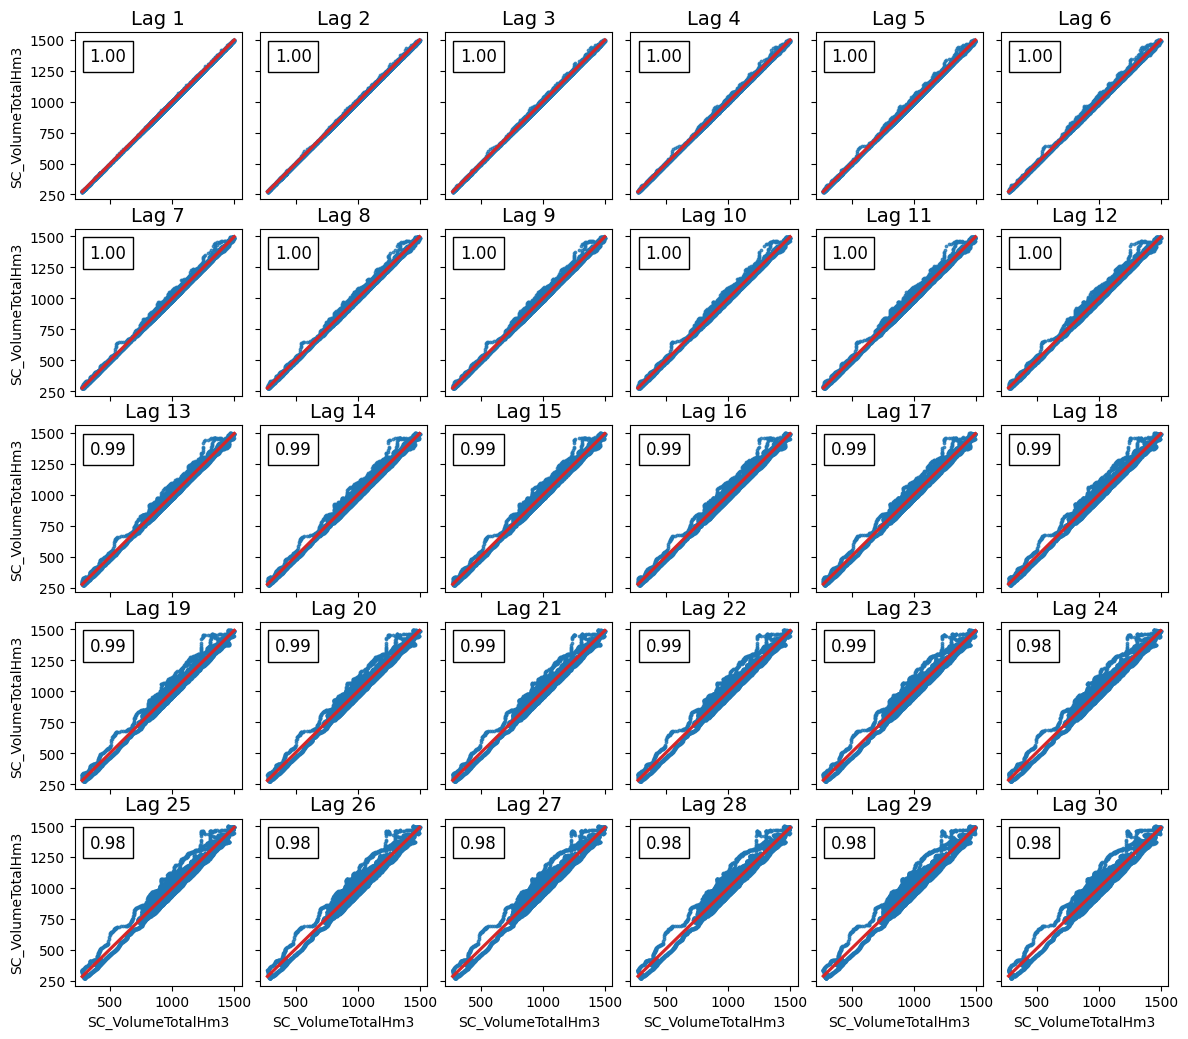

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df_volume_series, lags=15);
plot_lags(df_volume_series, lags=30, nrows=5);

# Modelagem

- Lags para Volume
- Leads para Vazão Natural e Jusante.

In [12]:
X_lags = make_lags(df_volume.squeeze(), 1)
X_Qin_leads = make_leads(df_vazao_natural.squeeze(), 1, name="Qin")
X_Qout_leads = make_leads(df_vazao_jusante.squeeze(), 1, name="Qout")

X_full = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()
display(X_full)

,y_lag_1,Qin_lead_0,Qout_lead_0
Data,,,
2000-01-02,1072.05098,94.864,10.18
2000-01-03,1077.19190,108.208,7.29
2000-01-04,1083.54730,162.936,6.34
2000-01-05,1094.42749,211.604,6.33
2000-01-06,1109.54794,59.722,5.40
...,...,...,...
2025-09-12,826.04165,6.368,11.60
2025-09-13,823.53813,6.849,11.60
2025-09-14,821.06142,7.133,11.60


In [13]:
VALIDATION_SIZE = 1*365
PREDICTION_SIZE = 90

y = df_volume_series.copy()
y, X_full = y.align(X_full, join='inner')

y_multistep_target = make_multistep_target(y, steps=PREDICTION_SIZE).dropna()
y_multistep_target, X = y_multistep_target.align(X_full, join='inner', axis=0)

X_train, X_valid, y_train, y_valid = train_test_split(X, y_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
X_train_rec, X_valid_rec, y_train_rec, y_valid_rec = train_test_split(X_full, y, test_size=VALIDATION_SIZE, shuffle=False)

In [14]:
dummy = DummyRegressor(strategy="constant", constant=0)

model1 = HybridRecursive(LinearRegression(fit_intercept=False), dummy, lags=1)
model1.fit(X_train_rec, y_train_rec)
model1.calculate_lags(X_valid_rec)

y_fit = model1.predict(X_train_rec)
y_pred = model1.predict(X_valid_rec)

metric = calculate_metrics(
  y.loc[y_fit.index],
  y.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

,RMSE,MSE,MAE,R2,Wasserstein
Treino,0.555683,0.308783,0.471418,0.999995,0.244241
Validação,0.302951,0.091779,0.259744,0.999982,0.220549


69606030


17269202


In [15]:
#eq_text = f"y = {model1.trend_model.intercept_[0]:.5f} + "
eq_text = f"y = {model1.trend_model.intercept_:.5f} + "
eq_text += " + ".join([f"{c:.5f}·X{i+1}" for i, c in enumerate(model1.trend_model.coef_[0])])
print(eq_text)

y = 0.00000 + 0.99779·X1 + 0.08403·X2 + -0.07439·X3


### Resultado

- Nesta primeira modelagem, o modelo tem por entrada o lag da variável Volume (modelo autoregressivo) e valores de lead para vazão de entrada e vazão de saída.
- Em um cenário real de predição, é necessário prever as vazões e utilizar a primeira previsão de volume como entrada para as próximas.
- Na próxima etapa, pretende-se implementar esta abordagem.


## Seleção de features

### Features para Vazão Natural

In [16]:
y_vn = df_vazao_natural_series[df_vazao_natural_series.index >= "2018-01-01"].copy()

fourier = CalendarFourier(freq="Y", order=2)
dp = DeterministicProcess(
  index=y_vn.index,
  constant=False,
  order=1,
  seasonal=False,
  additional_terms=[fourier],
  drop=True,
)
X_full_vn = dp.in_sample()

VALIDATION_SIZE = 1*365
PREDICTION_SIZE = 90

y_vn_multistep_target = make_multistep_target(y_vn, steps=PREDICTION_SIZE).dropna()
y_vn_multistep_target, X_vn = y_vn_multistep_target.align(X_full_vn, join='inner', axis=0)

X_vn_train, X_vn_valid, y_vn_train, y_vn_valid = train_test_split(X_vn, y_vn_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
X_vn_train_rec, X_vn_valid_rec, y_vn_train_rec, y_vn_valid_rec = train_test_split(X_full_vn, y_vn, test_size=VALIDATION_SIZE, shuffle=False)

### Features para Vazão Jusante

In [17]:
y_vj = df_vazao_jusante_series[df_vazao_jusante_series.index >= "2018-01-01"].copy()

fourier = CalendarFourier(freq="Y", order=2)
dp = DeterministicProcess(
  index=y_vj.index,
  constant=False,
  order=1,
  seasonal=False,
  additional_terms=[fourier],
  drop=True,
)
X_full_vj = dp.in_sample()

y_vj_multistep_target = make_multistep_target(y_vj, steps=PREDICTION_SIZE).dropna()
y_vj_multistep_target, X_vj = y_vj_multistep_target.align(X_full_vj, join='inner', axis=0)

X_vj_train, X_vj_valid, y_vj_train, y_vj_valid = train_test_split(X_vj, y_vj_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
X_vj_train_rec, X_vj_valid_rec, y_vj_train_rec, y_vj_valid_rec = train_test_split(X_full_vj, y_vj, test_size=VALIDATION_SIZE, shuffle=False)

### Features para Volume

In [18]:
def get_train_test_split_recursive():
  y_vol = df_volume_series[df_volume_series.index >= "2018-01-01"].copy()
  X_lags = make_lags(y_vol.squeeze(), 1)
  X_Qin_leads = make_leads(y_vn.squeeze(), 1, name="Qin")
  X_Qout_leads = make_leads(y_vj.squeeze(), 1, name="Qout")
  X_full_vol = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()

  y_vol, X_full_vol = y_vol.align(X_full_vol, join='inner', axis=0)

  X_vol_train_rec, X_vol_valid_rec, y_vol_train_rec, y_vol_valid_rec = train_test_split(X_full_vol, y_vol, test_size=VALIDATION_SIZE, shuffle=False)
  return y_vol, X_vol_train_rec, X_vol_valid_rec, y_vol_train_rec, y_vol_valid_rec

def get_train_test_split_direct():
  y_vol = df_volume_series[df_volume_series.index >= "2018-01-01"].copy()
  X_lags = make_lags(y_vol.squeeze(), 1)
  X_Qin_leads = make_leads(y_vn.squeeze(), 90, name="Qin")
  X_Qout_leads = make_leads(y_vj.squeeze(), 90, name="Qout")
  X_full_vol = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()

  y_vol, X_full_vol = y_vol.align(X_full_vol, join='inner', axis=0)

  y_vol_multistep_target = make_multistep_target(y_vol, steps=PREDICTION_SIZE).dropna()
  y_vol_multistep_target, X_vol = y_vol_multistep_target.align(X_full_vol, join='inner', axis=0)

  X_vol_train, X_vol_valid, y_vol_train, y_vol_valid = train_test_split(X_vol, y_vol_multistep_target, test_size=VALIDATION_SIZE, shuffle=False)
  return y_vol, X_vol_train, X_vol_valid, y_vol_train, y_vol_valid

y_vol_rec, X_vol_train_rec, X_vol_valid_rec, y_vol_train_rec, y_vol_valid_rec = get_train_test_split_recursive()
y_vol_dir, X_vol_train, X_vol_valid, y_vol_train, y_vol_valid = get_train_test_split_direct()

# Modelagem

In [76]:
class ModeloPrevisaoVolume():
  def __init__(self, base_model_trend, base_model_cycle, lags=1, estrategia_recursiva=False, estrategia_direta=False):
    if((estrategia_recursiva and estrategia_direta) or (not estrategia_recursiva and not estrategia_direta)):
      raise RuntimeError("Os parâmetros estrategia_recursiva e estrategia_direta precisam estar definidos (pelo menos um deve ser True)")

    self.base_model_trend = clone(base_model_trend)
    self.base_model_cycle = clone(base_model_cycle)
    self.lags = lags
    self.estrategia_recursiva = estrategia_recursiva
    self.estrategia_direta = estrategia_direta
    self.usar_jusante = False

  def get_features(self, X_future):
    return self.X_feat_hist.loc[X_future.index]

  def get_autoregressive_params(self, X_future):
    if(self.vol_history is None):
      raise RuntimeError("Treinar o modelo primeiro")
    while(X_future.index.max() not in self.vol_history.index):
      next_date = self.vol_history.index[-1] + pd.Timedelta(days=1)
      vol_column_name = self.vol_history.columns[0]
      new_row = pd.DataFrame({vol_column_name: [0.0]}, index=[next_date])
      try:
        X_exog_fore = X_future.loc[new_row.index]
      except KeyError:
        data = new_row.index.astype(str).to_list()[0]
        raise RuntimeError("A data "+data+" deve estar presente do dataframe para previsão.")
      
      new_hist = pd.concat([self.vol_history, new_row])
      new_hist.index.name = self.vol_history.index.name
      new_lags = make_lags((new_hist).squeeze(), self.lags)

      # Previsão Vazão de Entrada
      last_row_lag = new_lags.tail(1)
      y_vn_fore = self.modelo_vazao_natural.predict(X_exog_fore)
      y_vn_fore = pd.Series(y_vn_fore.values.ravel(), index=y_vn_fore.index)
      y_vn_fore.index.name = self.vol_history.index.name
      X_leads_Qin = make_leads(y_vn_fore, 1, name="Qin")

      if(self.usar_jusante):
        # Previsão Vazão de Saída
        y_vj_fore = self.modelo_vazao_jusante.predict(X_exog_fore)
        y_vj_fore = pd.Series(y_vj_fore.values.ravel(), index=y_vj_fore.index)
        y_vj_fore.index.name = self.vol_history.index.name
        X_leads_Qout = make_leads(y_vj_fore, 1, name="Qout")

        X_fore = pd.concat([last_row_lag, X_leads_Qin, X_leads_Qout], axis=1).dropna()
      else:
        X_fore = pd.concat([last_row_lag, X_leads_Qin], axis=1).dropna()

      self.modelo_volume.calculate_lags(X_fore)
      self.X_feat_hist = pd.concat([self.X_feat_hist, X_fore])
      y_new_volume = self.modelo_volume.predict(X_fore)

      vol_hist_predicted = pd.DataFrame(
        [{vol_column_name: x} for x in y_new_volume.values.ravel()],
        index=[next_date + i* pd.Timedelta(days=1) for i, _ in enumerate(y_new_volume)]
      )
      index_missing = vol_hist_predicted.index.difference(self.vol_history.index)
      self.vol_history = self.vol_history.reindex(
        self.vol_history.index.union(index_missing)
      )
      self.vol_history.loc[vol_hist_predicted.index, vol_column_name] = vol_hist_predicted.loc[vol_hist_predicted.index, vol_column_name]

  """ Calcula lags para variáveis exógenas """
  def calculate_lags(self, X_valid_rec):
    self.modelo_vazao_natural.calculate_lags(X_valid_rec)
    if(self.usar_jusante):
      self.modelo_vazao_jusante.calculate_lags(X_valid_rec)

  """ Treinamento para Vazão Natural """
  def fit_vazao_natural(self, X, y):
    if(self.estrategia_recursiva):
      # Lasso/KNeighborsRegressor
      self.modelo_vazao_natural = HybridRecursive(Lasso(), KNeighborsRegressor(), lags=2)
      self.modelo_vazao_natural.fit(X, y)
    if(self.estrategia_direta):
      # LinearRegression/XGBRegressor
      self.modelo_vazao_natural = HybridDirect(LinearRegression(), XGBRegressor(), lags=2)
      self.modelo_vazao_natural.fit(X, y)

  """ Treinamento para Vazão Jusante """
  def fit_vazao_jusante(self, X, y):
    self.usar_jusante = True
    if(self.estrategia_recursiva):
      # LinearRegression/RandomForestRegressor
      self.modelo_vazao_jusante = HybridRecursive(LinearRegression(), RandomForestRegressor(), lags=2)
      self.modelo_vazao_jusante.fit(X, y)
    if(self.estrategia_direta):
      # LinearRegression/RandomForestRegressor
      self.modelo_vazao_jusante = HybridDirect(LinearRegression(), RandomForestRegressor(), lags=2)
      self.modelo_vazao_jusante.fit(X, y)

  """ Treinamento para Volume """
  def fit(self, X, y):
    y_to_fit = y.copy() if isinstance(y, pd.DataFrame) else y.to_frame().copy()
    self.vol_history = y_to_fit
    if(self.estrategia_recursiva):
      self.modelo_volume = HybridRecursive(self.base_model_trend, self.base_model_cycle, lags=self.lags)
    if(self.estrategia_direta):
      self.modelo_volume = HybridDirect(self.base_model_trend, self.base_model_cycle, lags=self.lags)

    if(self.usar_jusante):
      self.modelo_volume.fit(X, y)
      self.X_feat_hist = X
    else:
      X_sem_jusante = X[[x for x in X.columns if not x.startswith("Qout_")]]
      self.modelo_volume.fit(X_sem_jusante, y)
      self.X_feat_hist = X_sem_jusante

  """ Predição """
  def predict(self, X_future):
    self.get_autoregressive_params(X_future)
    X_to_predict = self.get_features(X_future)
    return self.modelo_volume.predict(X_to_predict)

In [22]:
#dummy = DummyRegressor(strategy="constant", constant=0)
#model = ModeloPrevisaoVolume(LinearRegression(fit_intercept=False), dummy, lags=1, estrategia_direta=True)

#model.fit_vazao_natural(X_vn_train, y_vn_train)
#model.fit_vazao_jusante(X_vj_train, y_vj_train)
#model.calculate_lags(X_vn_valid)
#model.fit(X_vol_train, y_vol_train)

## Estratégia Recursiva

### Sem vazão jusante

In [ ]:
dummy = DummyRegressor(strategy="constant", constant=0)
model = ModeloPrevisaoVolume(LinearRegression(fit_intercept=False), dummy, lags=1, estrategia_recursiva=True)

model.fit_vazao_natural(X_vn_train_rec, y_vn_train_rec)
#model.fit_vazao_jusante(X_vj_train_rec, y_vj_train_rec)
model.calculate_lags(X_vn_valid_rec)
model.fit(X_vol_train_rec, y_vol_train_rec)

X_vn_train_rec_drop = X_vn_train_rec.drop(pd.Timestamp("2018-01-01"))
y_fit = model.predict(X_vn_train_rec_drop)
y_pred = model.predict(X_vn_valid_rec)

metric = calculate_metrics(
  y_vol_rec.loc[y_fit.index],
  y_vol_rec.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y_vol_rec.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y_vol_rec.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

,RMSE,MSE,MAE,R2,Wasserstein
Treino,0.393369,0.154739,0.307898,0.999993,0.221666
Validação,25.939690,672.867530,21.637734,0.867576,16.866780


11336701


87274726


### Com vazão jusante

In [78]:
dummy = DummyRegressor(strategy="constant", constant=0)
model = ModeloPrevisaoVolume(LinearRegression(fit_intercept=False), dummy, lags=1, estrategia_recursiva=True)

model.fit_vazao_natural(X_vn_train_rec, y_vn_train_rec)
model.fit_vazao_jusante(X_vj_train_rec, y_vj_train_rec)
model.calculate_lags(X_vn_valid_rec)
model.fit(X_vol_train_rec, y_vol_train_rec)

X_vn_train_rec_drop = X_vn_train_rec.drop(pd.Timestamp("2018-01-01"))
y_fit = model.predict(X_vn_train_rec_drop)
y_pred = model.predict(X_vn_valid_rec)

metric = calculate_metrics(
  y_vol_rec.loc[y_fit.index],
  y_vol_rec.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y_vol_rec.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y_vol_rec.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

c:\Users\marce\Desktop\Pos Graduacoes\UFSCAR - MachineLearningInProduction\AtividadesEntregas\4_TCC\codigo\tcc\.venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



,RMSE,MSE,MAE,R2,Wasserstein
Treino,0.329023,0.108256,0.269667,0.999995,0.193729
Validação,35.999619,1295.972576,30.964057,0.744946,28.267074


84280103


53694502


# Modelagem - Estratégia Direta

In [ ]:
class ModeloPrevisaoVolumeDireto():
  def fit_vazao_natural(self, X, y):
    # LinearRegression/XGBRegressor
    #self.modelo_vazao_entrada = 
    x=1
  def fit_vazao_jusante(self, X, y):
    # LinearRegression/RandomForestRegressor
    #self.modelo_vazao_jusante = 
    x=1
  def fit(self, X, y):
    x=1
  def predict(self, X_future):
    x=1

In [ ]:
dummy = DummyRegressor(strategy="constant", constant=0)
model = ModeloPrevisaoVolume(LinearRegression(fit_intercept=False), dummy, lags=1, estrategia_direta=True)

model.fit_vazao_natural(X_vn_train, y_vn_train)
#model.fit_vazao_jusante(X_vj_train, y_vj_train)
model.calculate_lags(X_vn_valid)
model.fit(X_vol_train, y_vol_train)

X_vn_train_drop = X_vn_train.drop(pd.Timestamp("2018-01-01"))
y_fit = model.predict(X_vn_train_drop)
y_pred = model.predict(X_vn_valid)

metric = calculate_metrics(
  y_vol_dir.loc[y_fit.index],
  y_vol_dir.loc[y_pred.index],
  y_fit.squeeze(),
  y_pred.squeeze()
)
display(metric)

fig1 = plot_plotly(
  y_vol_dir.loc[y_fit.index],
  y_fit,
  title="Forecast - Treino",
  showlegend=True
)

fig2 = plot_plotly(
  y_vol_dir.loc[y_pred.index],
  y_pred,
  title="Forecast - Validação",
  showlegend=True
)

IndexError: tuple index out of range

### Codigo de teste

In [ ]:
dummy = DummyRegressor(strategy="constant", constant=0)
model = ModeloPrevisaoVolume(LinearRegression(fit_intercept=False), dummy, lags=1, estrategia_direta=True)

model.fit_vazao_natural(X_vn_train_rec, y_vn_train_rec)
#model.fit_vazao_jusante(X_vj_train_rec, y_vj_train_rec)
model.calculate_lags(X_vn_valid_rec)
model.fit(X_vol_train_rec, y_vol_train_rec)

In [ ]:
next_date = model.vol_history.index[-1] + pd.Timedelta(days=1)
vol_column_name = model.vol_history.columns[0]
new_row = pd.DataFrame({vol_column_name: [0.0]}, index=[next_date])

new_hist = pd.concat([model.vol_history, new_row])
new_hist.index.name = model.vol_history.index.name
new_lags = make_lags((new_hist).squeeze(), model.lags)

last_row_lag = new_lags.tail(1)

X_exog_fore = X_vn_valid_rec.loc[new_row.index]

y_vn_fore = model.modelo_vazao_natural.predict(X_exog_fore)
y_vn_fore = pd.Series(y_vn_fore.values.ravel(), index=y_vn_fore.index)
y_vn_fore.index.name = model.vol_history.index.name
print(y_vn_fore)
X_leads_Qin = make_leads(y_vn_fore, 1, name="Qin")

X_fore = pd.concat([last_row_lag, X_leads_Qin], axis=1).dropna()
model.modelo_volume.calculate_lags(X_fore)
y_new_volume = model.modelo_volume.predict(X_fore)

vol_hist_predicted = pd.DataFrame(
  [{vol_column_name: x} for x in y_new_volume.values.ravel()],
  index=[next_date + i* pd.Timedelta(days=1) for i, _ in enumerate(y_new_volume)]
)

index_missing = vol_hist_predicted.index.difference(model.vol_history.index)
model.vol_history = model.vol_history.reindex(
  model.vol_history.index.union(index_missing)
)
model.vol_history.loc[vol_hist_predicted.index, vol_column_name] = vol_hist_predicted.loc[vol_hist_predicted.index, vol_column_name]
model.vol_history

Data
2024-09-17    6.876037
dtype: float64


,SC_VolumeTotalHm3
2018-01-02,920.676610
2018-01-03,920.549750
2018-01-04,921.932110
2018-01-05,921.893220
2018-01-06,921.325220
...,...
2024-09-13,1049.319450
2024-09-14,1047.098640
2024-09-15,1044.839310
2024-09-16,1042.904940


next_date = model.vol_history.index[-1] + pd.Timedelta(days=1)
vol_column_name = model.vol_history.columns[0]
new_row = pd.DataFrame({vol_column_name: [0.0]}, index=[next_date])

new_hist = pd.concat([model.vol_history, new_row])
new_hist.index.name = model.vol_history.index.name
new_lags = make_lags((new_hist).squeeze(), model.lags)

last_row_lag = new_lags.tail(1)

X_exog_fore = X_vn_valid_rec.loc[new_row.index]

y_vn_fore = model.modelo_vazao_natural.predict(X_exog_fore)
y_vn_fore = pd.Series(y_vn_fore.values.ravel(), index=y_vn_fore.index)
y_vn_fore.index.name = model.vol_history.index.name
X_leads_Qin = make_leads(y_vn_fore, 1, name="Qin")

X_fore = pd.concat([last_row_lag, X_leads_Qin], axis=1).dropna()
model.modelo_volume.calculate_lags(X_fore)
y_new_volume = model.modelo_volume.predict(X_fore)

vol_hist_predicted = pd.DataFrame(
  [{vol_column_name: x} for x in y_new_volume.values.ravel()],
  index=[next_date + i* pd.Timedelta(days=1) for i, _ in enumerate(y_new_volume)]
)

index_missing = vol_hist_predicted.index.difference(model.vol_history.index)
model.vol_history = model.vol_history.reindex(
  model.vol_history.index.union(index_missing)
)
model.vol_history.loc[vol_hist_predicted.index, vol_column_name] = vol_hist_predicted.loc[vol_hist_predicted.index, vol_column_name]
model.vol_history